In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.spatial import ConvexHull

## 1.Fundemental Diagram Calibration

#### v-k

In [ ]:
# Load the data from the CSV files

density_df = pd.read_csv('Linknumber_sim.csv')
speed_df = pd.read_csv('Linkspeed_sim.csv')

# Print the first few rows to understand the structure
density_df.columns = ['link_id'] + list(density_df.columns[1:])
speed_df.columns = ['link_id'] + list(speed_df.columns[1:])
# print(density_df.head())
# print(speed_df.head())

# Melt both dataframes to long format
link_number_melted = density_df.melt(id_vars=['link_id'], var_name='time_step', value_name='vehicle_number')
link_speed_melted = speed_df.melt(id_vars=['link_id'], var_name='time_step', value_name='speed')

# Merge the melted dataframes on link_id and time_step
merged_df = pd.merge(link_number_melted, link_speed_melted, on=['link_id', 'time_step'])

# Extract the numerical part of the time step
merged_df['time_step'] = merged_df['time_step'].str.extract('(\d+)').astype(int)

# Plot the scatter plot
plt.figure(figsize=(14, 8))
scatter = plt.scatter(merged_df['vehicle_number'], merged_df['speed'], c=merged_df['time_step'], cmap='viridis', s=5, alpha=0.7)
# scatter = plt.scatter(merged_df['vehicle_number'], merged_df['speed'], alpha=0.7)

plt.colorbar(scatter, label='Time Step')
plt.title('Scatter Plot of Density vs Speed')
plt.xlabel('Density')
plt.ylabel('Speed')
plt.show()

#### Flow Density FD

<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1128316/3513824220.py:24: SyntaxWarning: invalid escape sequence '\d'
  merged_df['time_step'] = merged_df['time_step'].str.extract('(\d+)').astype(int)


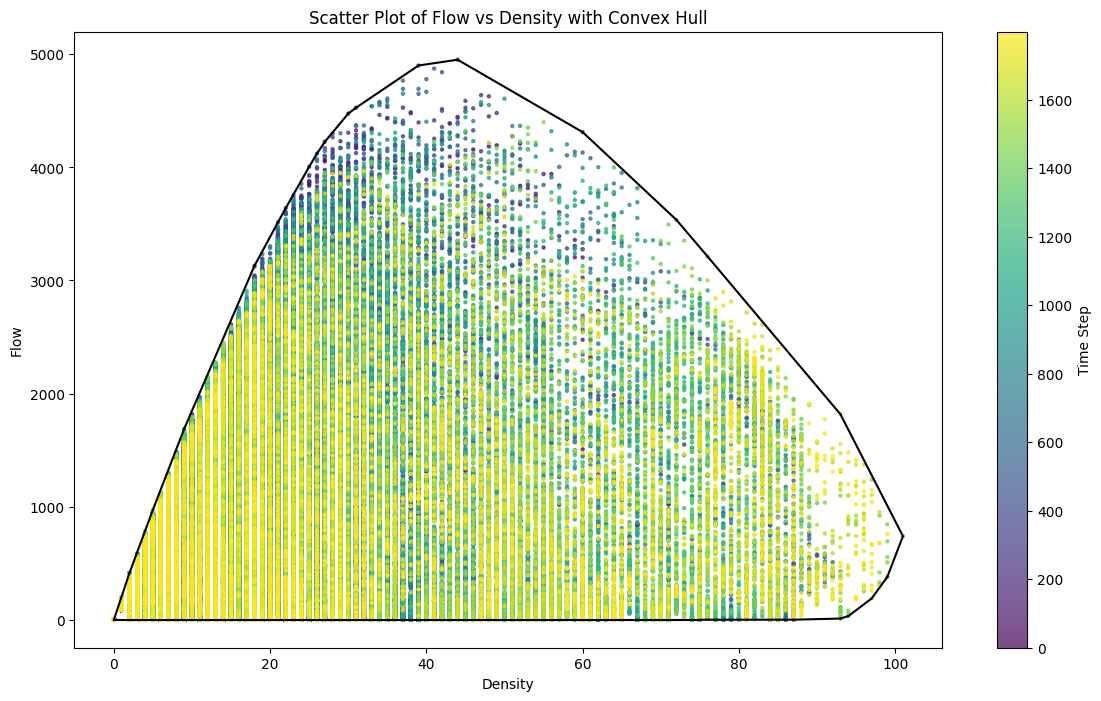

In [101]:
# Load the data from the CSV files

# Load the data from the CSV files
density_df_path = 'Linknumber_sim.csv'
flow_df_path = 'Flow_sim.csv'

density_df = pd.read_csv(density_df_path)
flow_df = pd.read_csv(flow_df_path)

# Print the first few rows to understand the structure
density_df.columns = ['link_id'] + list(density_df.columns[1:])
flow_df.columns = ['link_id'] + list(flow_df.columns[1:])
# print(density_df.head())
# print(flow_df.head())

# Melt both dataframes to long format
link_number_melted = density_df.melt(id_vars=['link_id'], var_name='time_step', value_name='vehicle_number')
link_flow_melted = flow_df.melt(id_vars=['link_id'], var_name='time_step', value_name='speed')

# Merge the melted dataframes on link_id and time_step
merged_df = pd.merge(link_number_melted, link_flow_melted, on=['link_id', 'time_step'])

# Extract the numerical part of the time step
merged_df['time_step'] = merged_df['time_step'].str.extract('(\d+)').astype(int)

# Extract the points for the scatter plot
points = merged_df[['vehicle_number', 'speed']].values

# Calculate the convex hull
hull = ConvexHull(points)

# Plot the scatter plot
plt.figure(figsize=(14, 8))
scatter = plt.scatter(merged_df['vehicle_number'], merged_df['speed'], c=merged_df['time_step'], cmap='viridis', s=5, alpha=0.7)
plt.colorbar(scatter, label='Time Step')

# Plot the convex hull
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'k-')

plt.title('Scatter Plot of Flow vs Density with Convex Hull')
plt.xlabel('Density')
plt.ylabel('Flow')
plt.show()


## CTM Preprocess

In [103]:
# Step 1: Load the CSV File and Convert to DataFrame
time_id_matrix_path = 'CTMnumber_600_2400.csv'
time_id_matrix = pd.read_csv(time_id_matrix_path)

# Display the first few rows to understand the structure
# print(time_id_matrix.head())

# Step 2: Combine Cell Numbers by Link
# Extract the link ID from the cell ID
time_id_matrix['link_id'] = time_id_matrix.iloc[:, 0].apply(lambda x: x.split('.')[1])

# Group by link ID and sum the number of vehicles for each time step
link_grouped = time_id_matrix.groupby('link_id').sum()

# Drop the cell ID column (first column)
link_grouped = link_grouped.drop(columns=time_id_matrix.columns[0])

# Display the first few rows of the grouped DataFrame
# print(link_grouped.head())

In [104]:
link_grouped.to_csv('CTMcombinedVehNum.csv')

## 2.CTM Performance Evaluation

In [102]:
def plot_vehicles_over_time(dataframe, time_resolution=1):
    """
    Plots the number of vehicles over time for each link.

    Parameters:
    dataframe (pd.DataFrame): DataFrame with columns ['link_id', 'time_1', 'time_2', ..., 'time_n'].
    time_resolution (int): Interval for time steps to plot.

    Returns:
    None: Displays a plot.
    """
    
    # Melt the dataframe to have columns ['link_id', 'time_step', 'vehicle_number']
    melted_df = dataframe.melt(id_vars=['link_id'], var_name='time_step', value_name='vehicle_number')
    
    # Extract the numerical part of the time step
    melted_df['time_step'] = melted_df['time_step'].str.extract('(\d+)').astype(int)
    
    # Filter based on the time resolution
    melted_df = melted_df[melted_df['time_step'] % time_resolution == 0]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Set the color palette
    palette = sns.color_palette("hsv", len(melted_df['link_id'].unique()))
    color_mapping = dict(zip(melted_df['link_id'].unique(), palette))
    
    # Plot each link with a different color
    for link_id in melted_df['link_id'].unique():
        link_data = melted_df[melted_df['link_id'] == link_id]
        ax.plot(link_data['time_step'], link_data['vehicle_number'], label=link_id, color=color_mapping[link_id])
        
    ax.set_title('Number of Vehicles Over Time for Each Link')
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Number of Vehicles')
    ax.legend(title='Link ID', bbox_to_anchor=(1.25, 1), loc='upper left')
    
    plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\d'
<>:17: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1128316/3345540934.py:17: SyntaxWarning: invalid escape sequence '\d'
  melted_df['time_step'] = melted_df['time_step'].str.extract('(\d+)').astype(int)


### Visulization

In [105]:
# Example usage:
# Load the example data
ctm_number_path = 'CTMcombinedVehNum.csv'
sim_number_path = 'Linknumber_sim.csv'

ctm_veh_num_df = pd.read_csv(ctm_number_path)
sim_veh_num_df = pd.read_csv(sim_number_path)

sim_veh_num_df.columns = ['link_id'] + list(sim_veh_num_df.columns[1:])

# Define the link IDs to visualize
link_ids_to_visualize = ['E1', 'E2', 'E3']


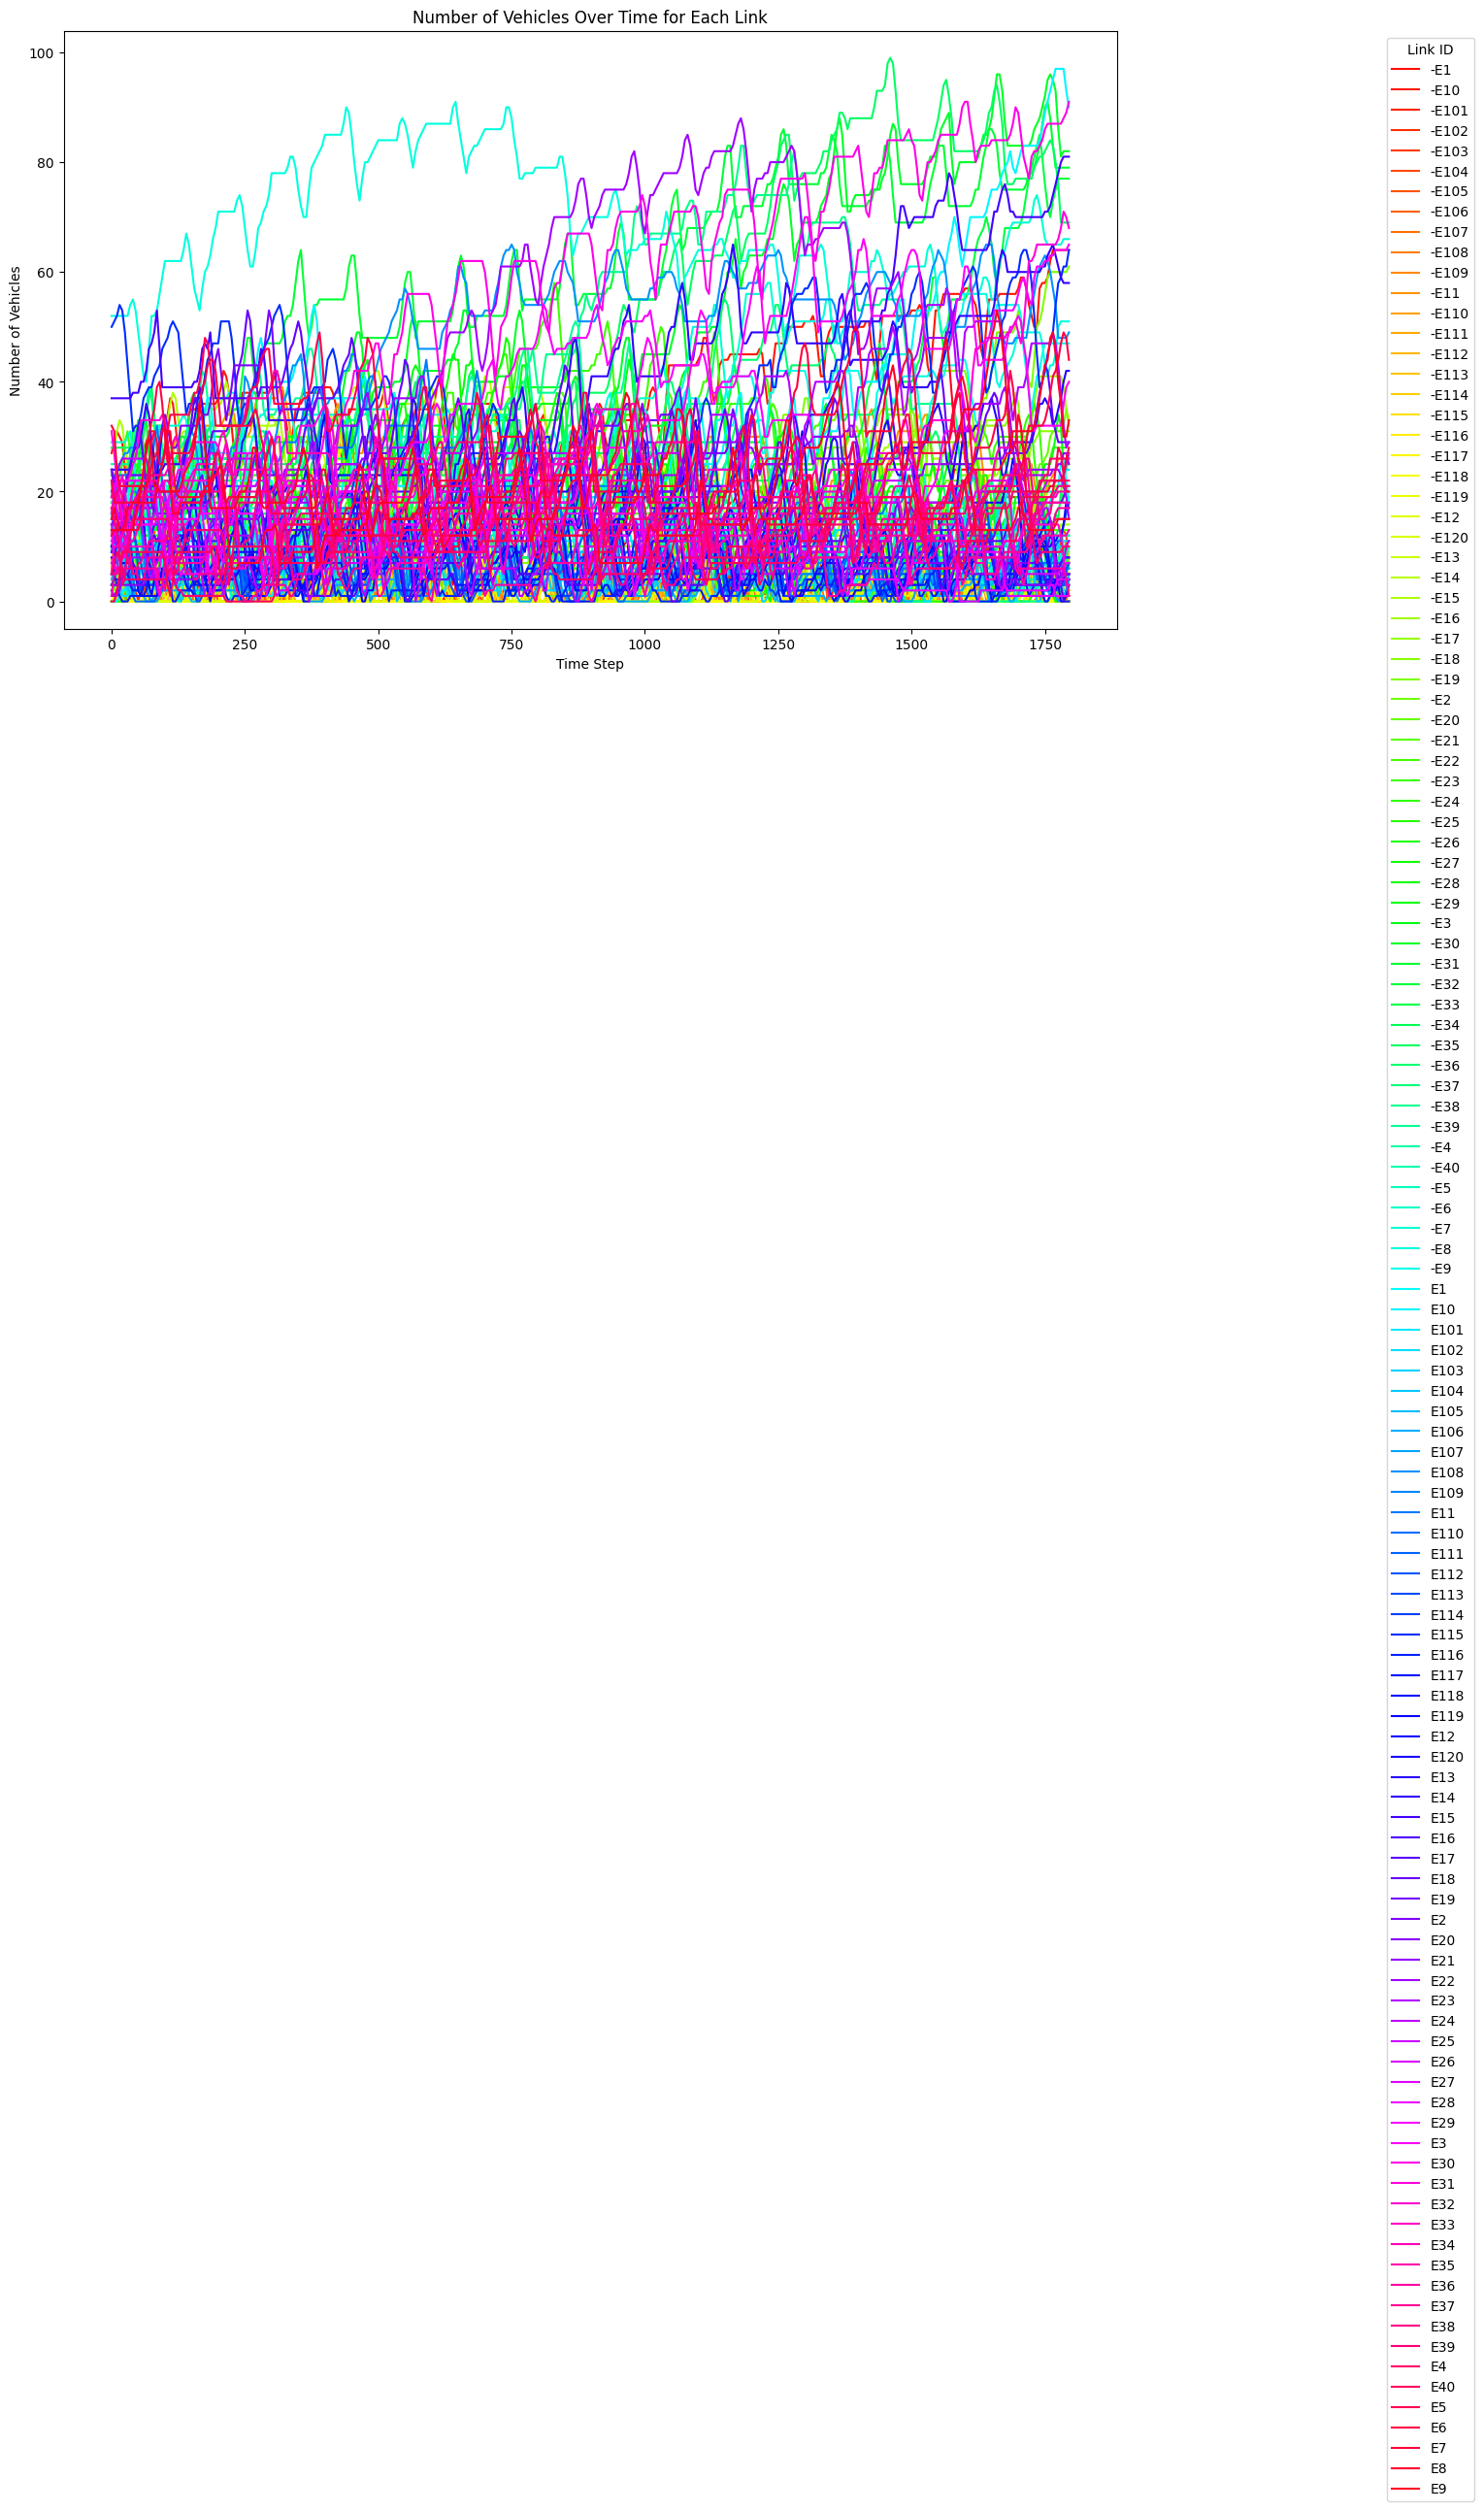

In [97]:
plot_vehicles_over_time(sim_veh_num_df, 5)

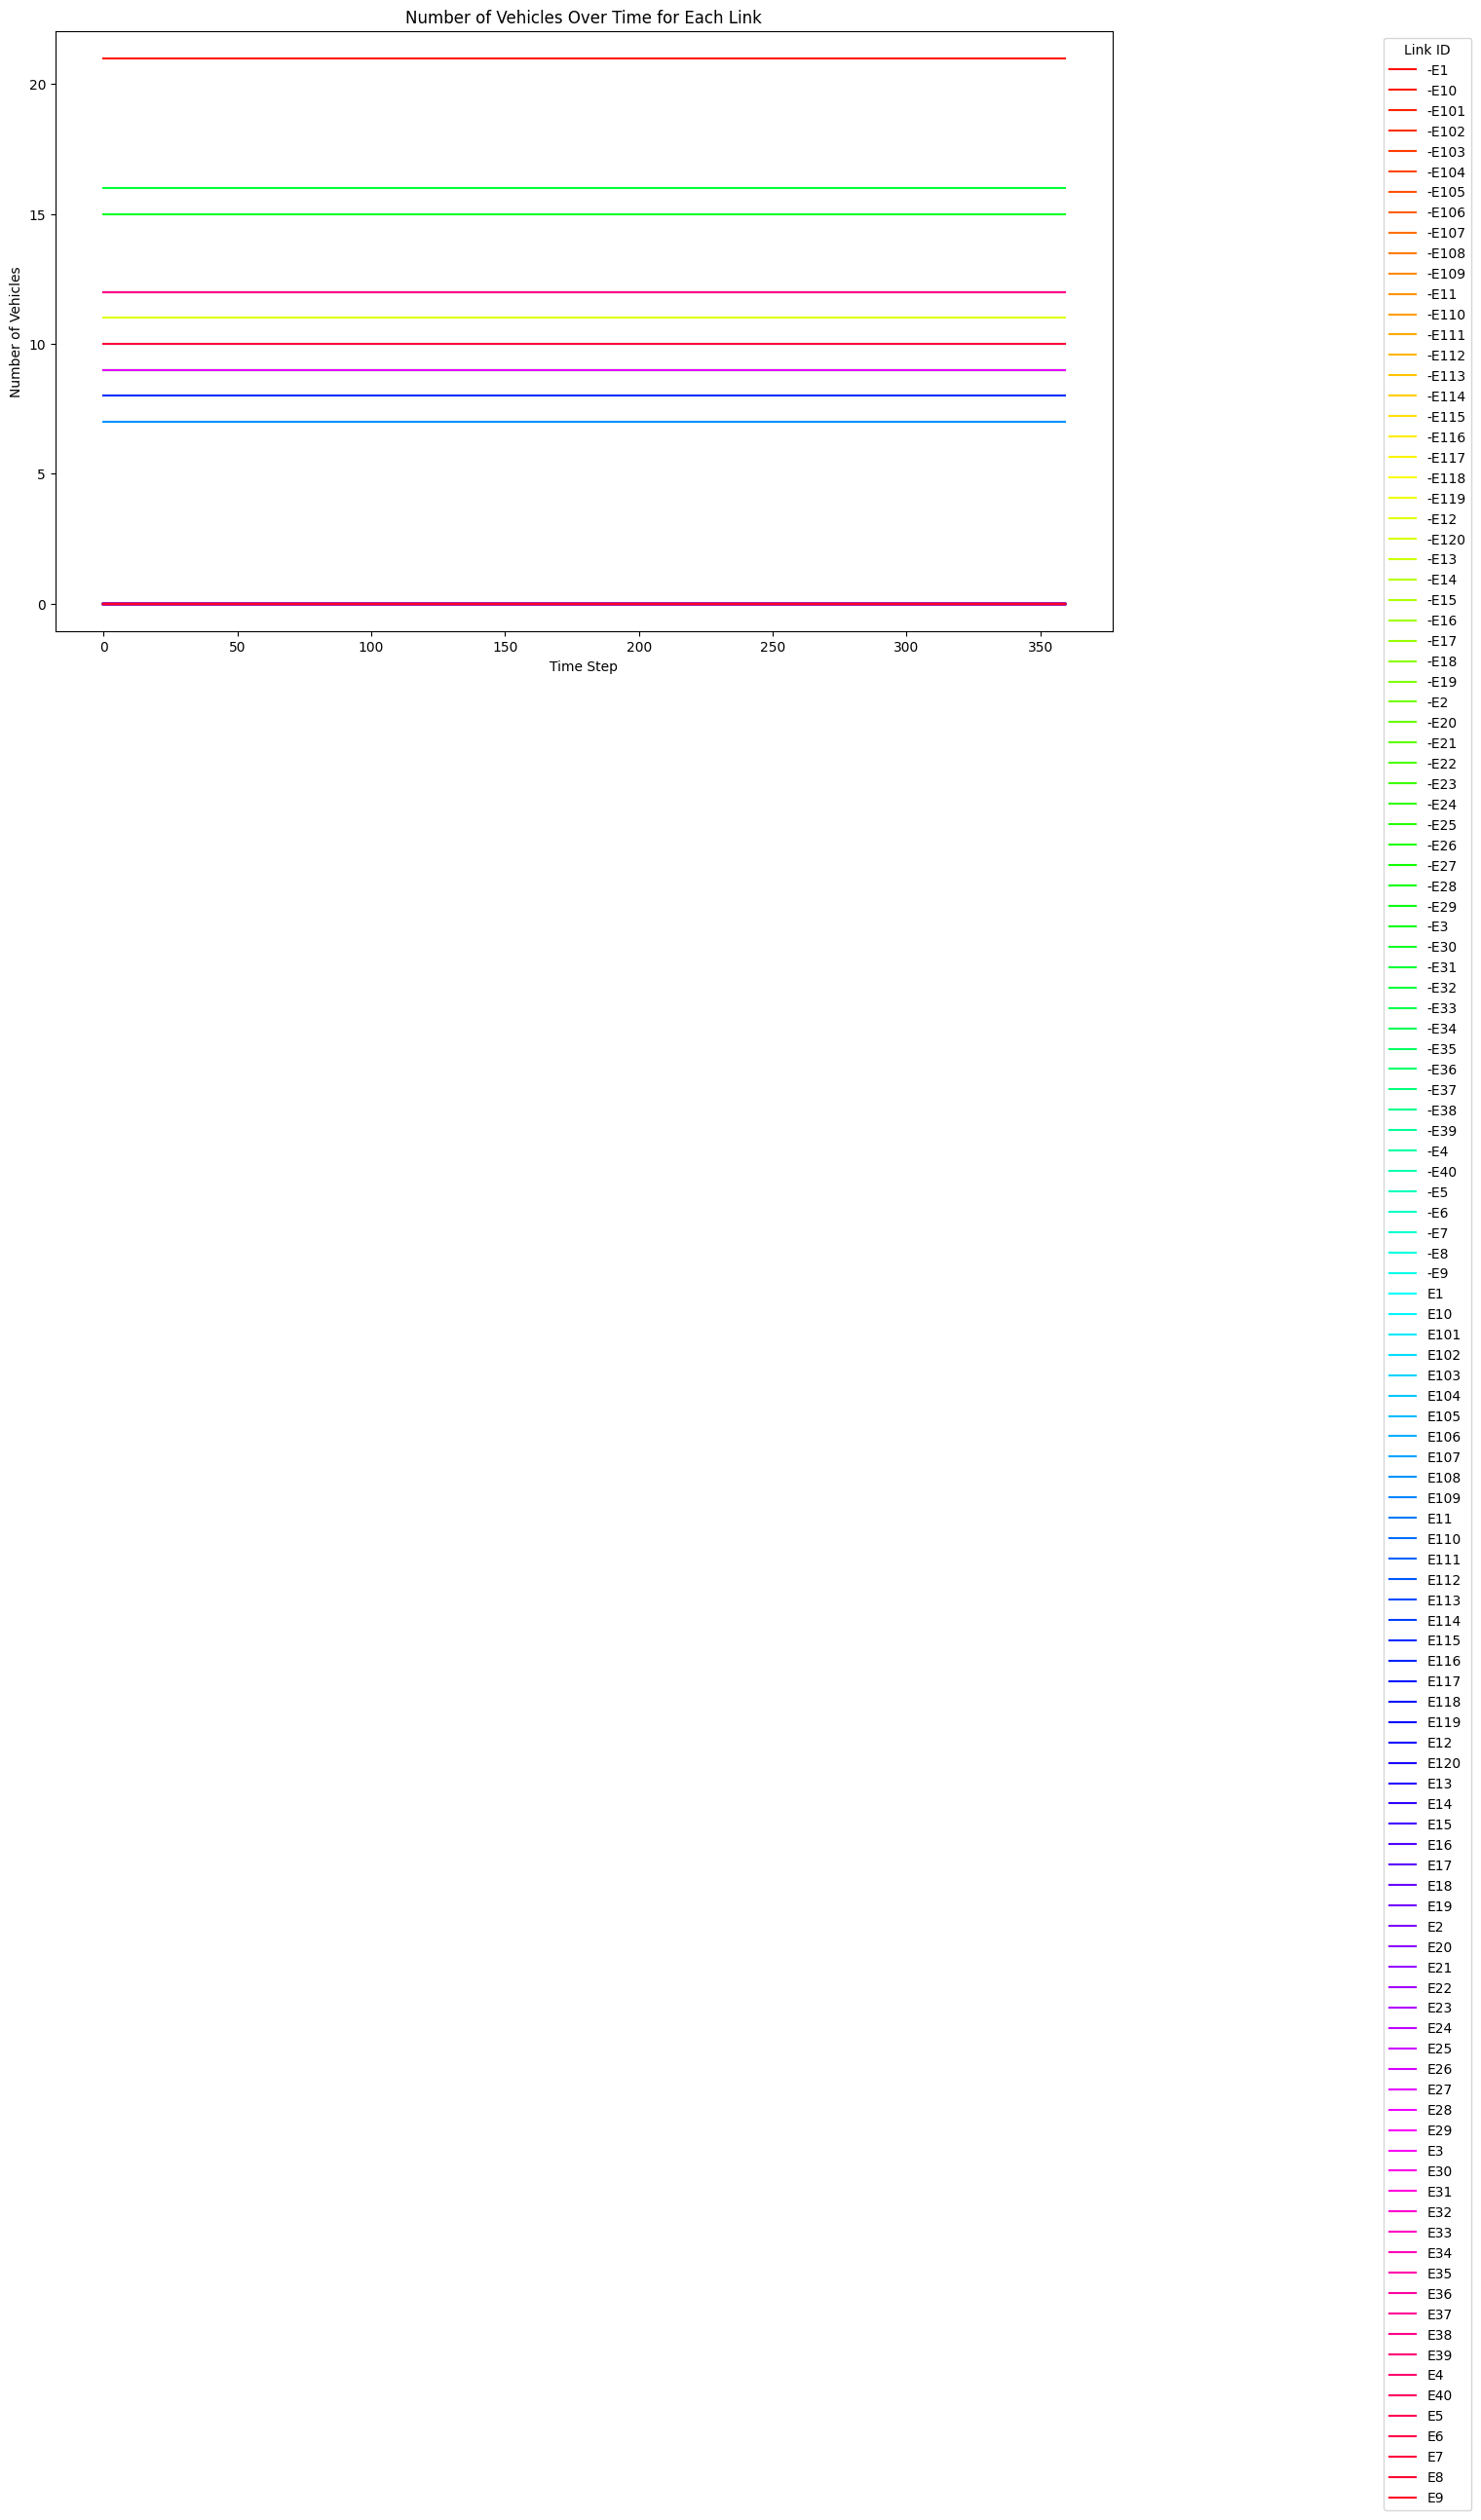

In [98]:
plot_vehicles_over_time(ctm_veh_num_df, 1)

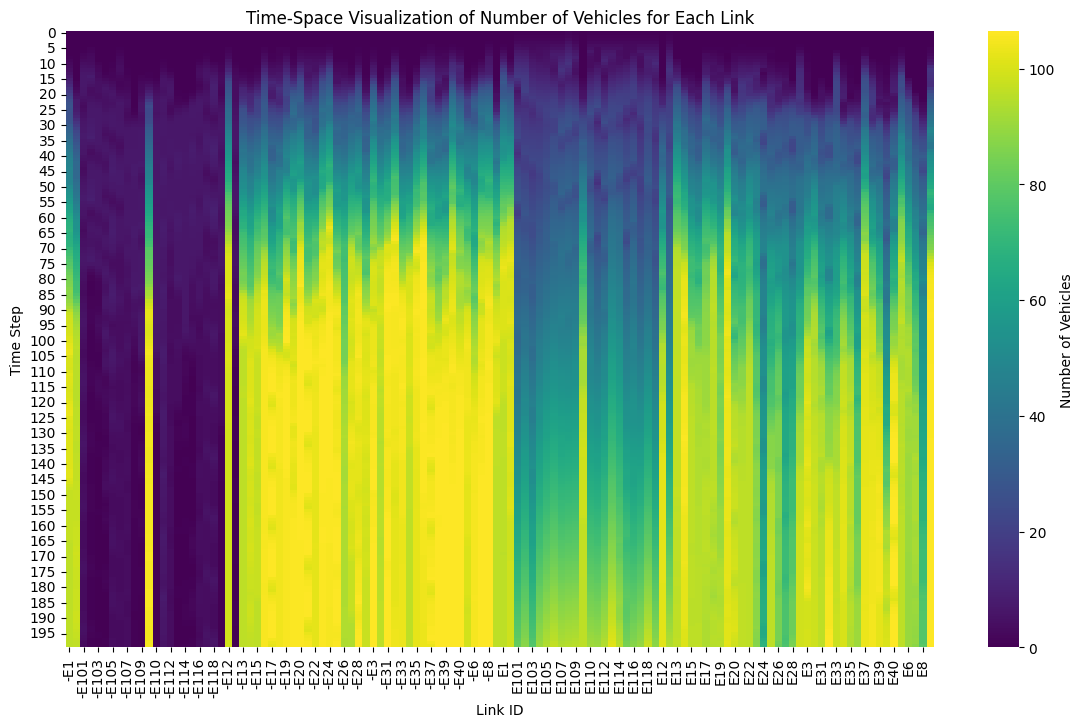

In [3]:
# Step 3: Create Time-Space Visualization
# Transpose the DataFrame to have time steps as columns
link_grouped_transposed = link_grouped.T

# Plot the heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(link_grouped_transposed, cmap='viridis', cbar_kws={'label': 'Number of Vehicles'})
plt.title('Time-Space Visualization of Number of Vehicles for Each Link')
plt.xlabel('Link ID')
plt.ylabel('Time Step')
plt.show()

### SUMO sim results